Name - Sandesh Arun Mohite

Roll No - 23

Division - T.Y(AIML)-A

# Decision Tree Classification (Gini Index) — UCI Heart Disease Dataset

**Problem Statement:** Predict whether a patient has heart disease (`target` = 1) or not (`target` = 0), based on 13 clinical and diagnostic features.

**Why this dataset?**
- 13 independent features — a good mix of continuous (age, cholesterol, blood pressure) and categorical/ordinal (chest pain type, ECG results, thalassemia) variables.
- A real, high-stakes healthcare use case, which makes the *interpretability* of a Decision Tree especially meaningful — a doctor can actually read the rules.
- 303 patient records — small enough to visualize a full tree without it becoming unreadable.

**What this notebook covers:**
1. Load and explore the dataset
2. Exploratory Data Analysis (EDA) with visualizations
3. Preprocessing and Train/Test split
4. Build a Decision Tree Classifier using the **Gini Index** as the splitting criterion
5. Evaluate the model (accuracy, confusion matrix, classification report, ROC-AUC)
6. **Visualize the full decision tree**
7. **Extract human-readable decision rules** from the trained tree
8. Feature importance analysis
9. Effect of `max_depth` on performance (bias-variance tradeoff)


## 1. Import Required Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


## 2. Load the Dataset

We use the **UCI Heart Disease** dataset (Cleveland subset), a widely used benchmark dataset in medical ML research, loaded directly from a public CSV source. It contains 303 patient records with 13 features plus the target label.

| Feature | Description |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment (0-2) |
| ca | Number of major vessels colored by fluoroscopy (0-4) |
| thal | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| **target** | **1 = heart disease present, 0 = absent (this is what we predict)** |


In [8]:
url = "/content/drive/MyDrive/heart.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 3. Exploratory Data Analysis (EDA)

In [11]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


/tmp/ipykernel_456/4148428831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#e74c3c', '#2ecc71'])


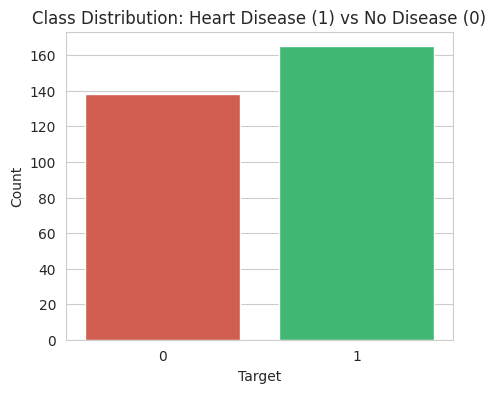

target
1    54.5
0    45.5
Name: proportion, dtype: float64 % of total


In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Class Distribution: Heart Disease (1) vs No Disease (0)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

print(df['target'].value_counts(normalize=True).round(3) * 100, "% of total")


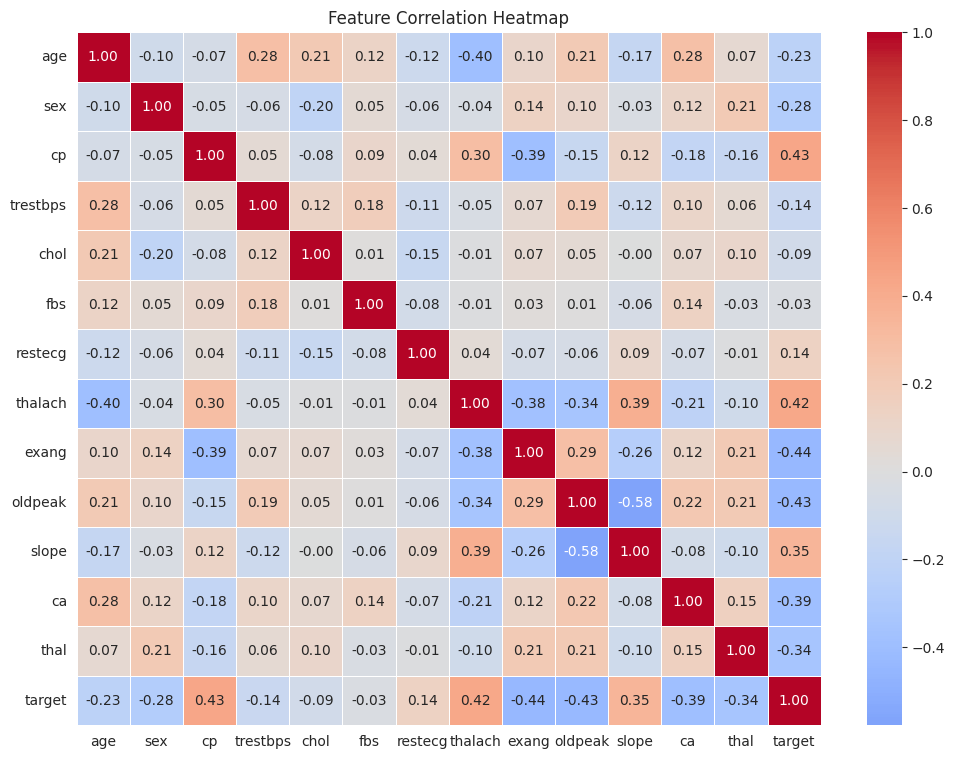

In [13]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


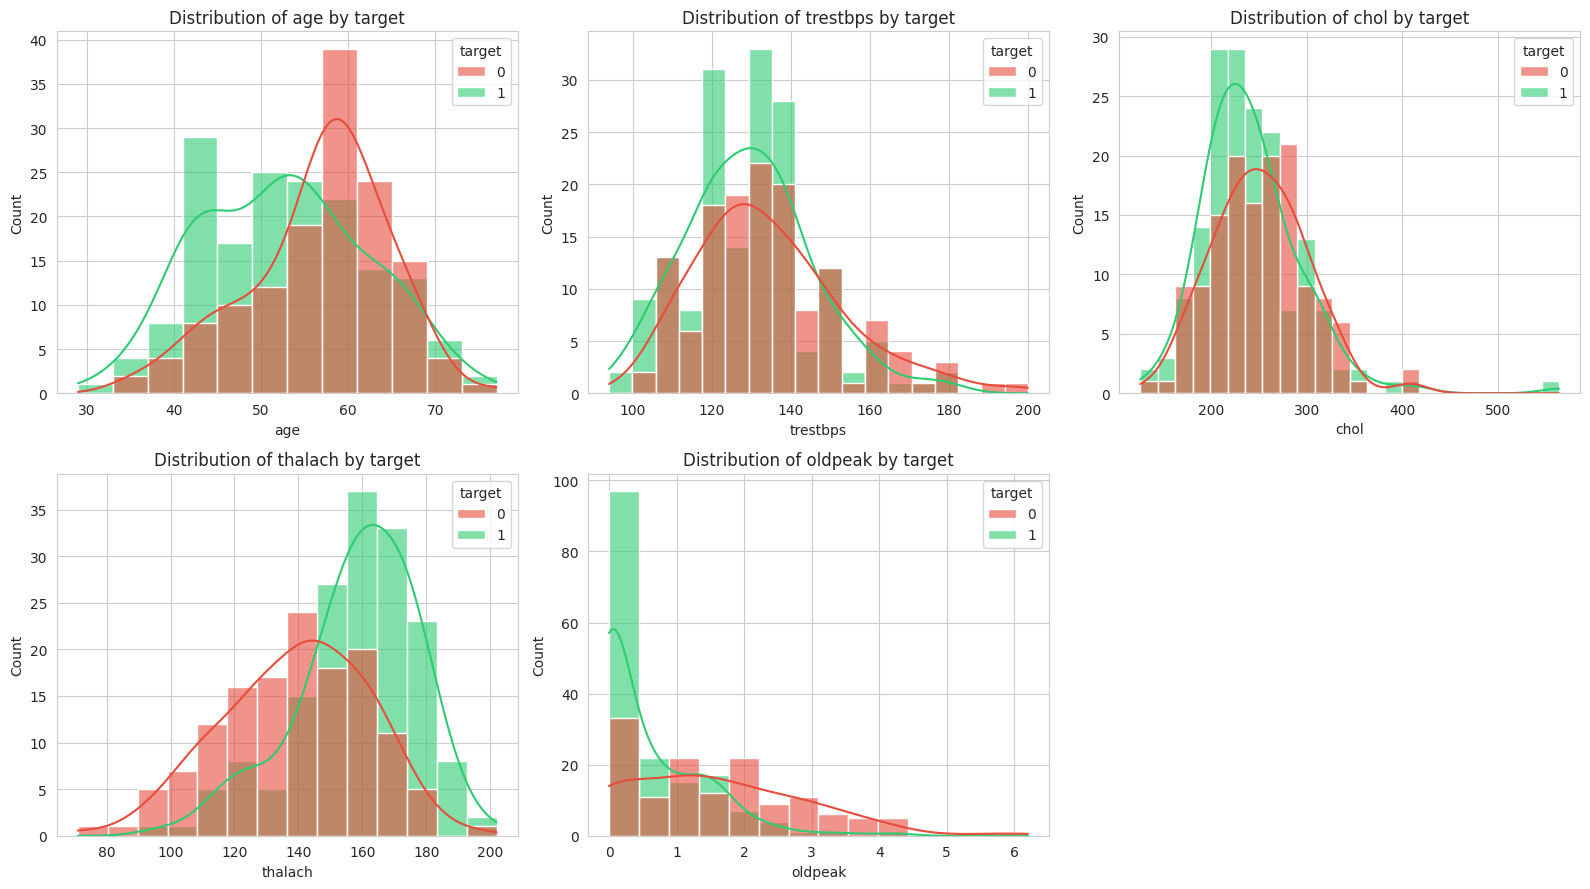

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for ax, col in zip(axes.flatten(), num_features):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
    ax.set_title(f'Distribution of {col} by target')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()


## 4. Prepare Data for Modeling

All features here are already numeric (categorical variables like `cp`, `restecg`, `thal` are label/ordinal-encoded in the source dataset), so no additional encoding is required. We split into features (`X`) and target (`y`), then into train/test sets.

In [15]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (242, 13)
Test shape : (61, 13)


## 5. Build the Decision Tree Classifier (Gini Index)

The **Gini Index** measures the impurity of a node:

$$Gini = 1 - \sum_{i=1}^{c} p_i^2$$

where $p_i$ is the probability of class $i$ at that node. A Gini value of 0 means the node is pure (all samples belong to one class); a value closer to 0.5 (for binary classification) means maximum impurity. At each split, the tree picks the feature/threshold that produces the **largest reduction in weighted Gini impurity** (i.e., highest Gini Gain) between the parent and child nodes.

We first train a tree with `max_depth=4` (for a clean, interpretable visualization), then compare against a fully-grown tree.

In [16]:
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

dt_gini.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

## 6. Model Evaluation

In [17]:
y_pred = dt_gini.predict(X_test)
y_prob = dt_gini.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Test Accuracy: 0.7869

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.86      0.64      0.73        28
     Disease       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



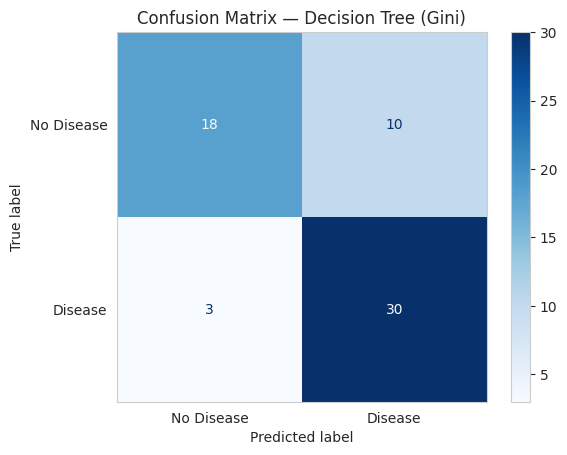

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Decision Tree (Gini)')
plt.grid(False)
plt.show()


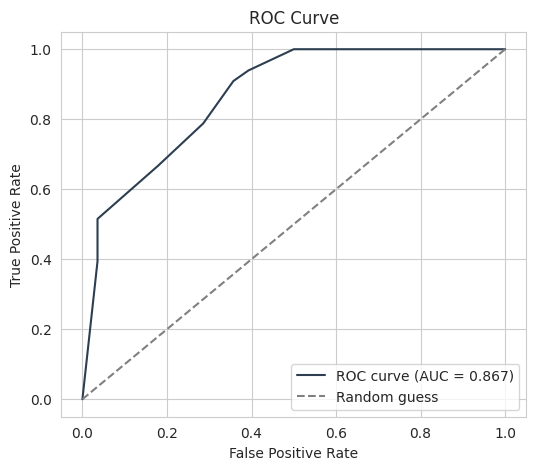

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})', color='#2c3e50')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 7. Visualize the Decision Tree

This is the biggest advantage of Decision Trees over black-box models — we can literally see and explain every decision path.

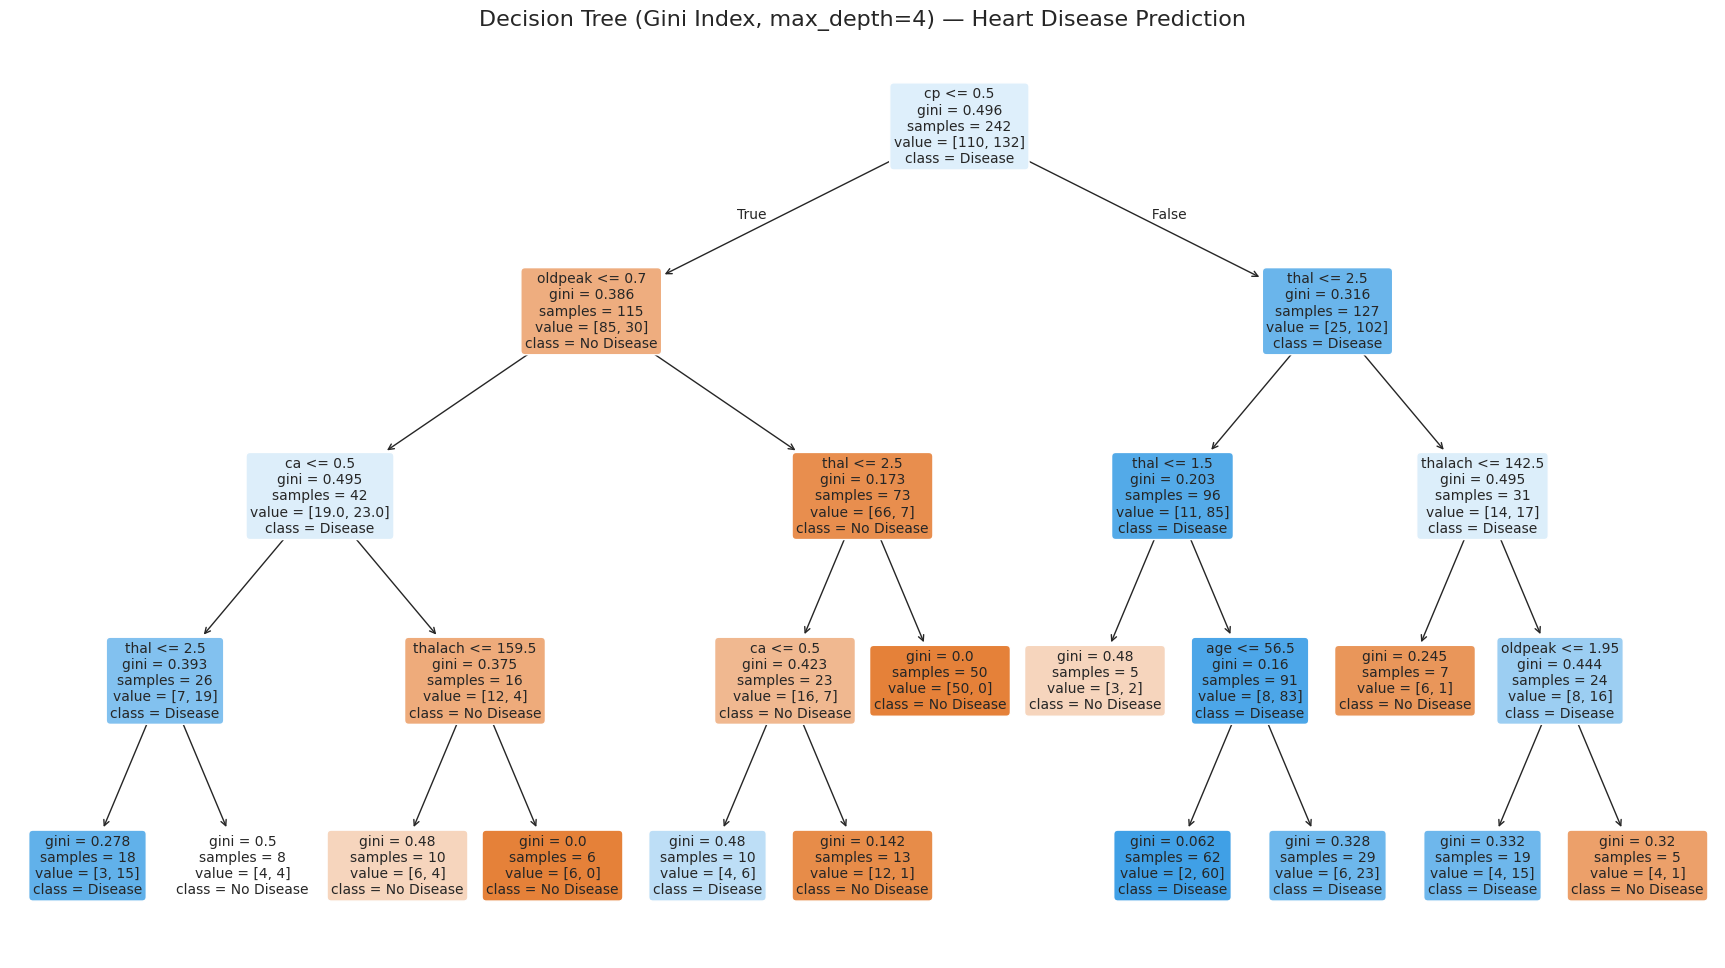

In [20]:
plt.figure(figsize=(22, 12))
plot_tree(
    dt_gini,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False,
    impurity=True
)
plt.title("Decision Tree (Gini Index, max_depth=4) — Heart Disease Prediction", fontsize=16)
plt.show()


## 8. Extract Decision Rules

`sklearn.tree.export_text` converts the trained tree into readable `if/else` rules — exactly the logic the model uses to classify each new patient.

In [21]:
rules_text = export_text(dt_gini, feature_names=list(X.columns))
print(rules_text)


|--- cp <= 0.50
|   |--- oldpeak <= 0.70
|   |   |--- ca <= 0.50
|   |   |   |--- thal <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- thal >  2.50
|   |   |   |   |--- class: 0
|   |   |--- ca >  0.50
|   |   |   |--- thalach <= 159.50
|   |   |   |   |--- class: 0
|   |   |   |--- thalach >  159.50
|   |   |   |   |--- class: 0
|   |--- oldpeak >  0.70
|   |   |--- thal <= 2.50
|   |   |   |--- ca <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- ca >  0.50
|   |   |   |   |--- class: 0
|   |   |--- thal >  2.50
|   |   |   |--- class: 0
|--- cp >  0.50
|   |--- thal <= 2.50
|   |   |--- thal <= 1.50
|   |   |   |--- class: 0
|   |   |--- thal >  1.50
|   |   |   |--- age <= 56.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  56.50
|   |   |   |   |--- class: 1
|   |--- thal >  2.50
|   |   |--- thalach <= 142.50
|   |   |   |--- class: 0
|   |   |--- thalach >  142.50
|   |   |   |--- oldpeak <= 1.95
|   |   |   |   |--- class: 1
|   |   |   |--- oldpeak >  1.95


### 8.1 Extract Rules as Clean, Plain-English Sentences (Leaf-Level Paths)

The code below walks every root-to-leaf path in the tree and converts it into a natural-language decision rule, which is often more useful than raw sklearn output when presenting to non-technical stakeholders (e.g., doctors).

In [22]:
def extract_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules = []

    def recurse(node, path):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_path = path + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], left_path)

            right_path = path + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], right_path)
        else:  # leaf node
            values = tree_.value[node][0]
            predicted_class = class_names[int(np.argmax(values))]
            n_samples = int(values.sum())
            confidence = values.max() / values.sum() * 100
            rule = "IF " + " AND ".join(path) + \
                   f"  =>  THEN predict '{predicted_class}'" \
                   f"  (confidence: {confidence:.1f}%, samples: {n_samples})"
            rules.append(rule)

    recurse(0, [])
    return rules


rules = extract_rules(dt_gini, list(X.columns), ['No Disease', 'Disease'])

print(f"Total decision rules extracted: {len(rules)}\n")
for i, r in enumerate(rules, 1):
    print(f"Rule {i}: {r}\n")


Total decision rules extracted: 13

Rule 1: IF cp <= 0.50 AND oldpeak <= 0.70 AND ca <= 0.50 AND thal <= 2.50  =>  THEN predict 'Disease'  (confidence: 83.3%, samples: 1)

Rule 2: IF cp <= 0.50 AND oldpeak <= 0.70 AND ca <= 0.50 AND thal > 2.50  =>  THEN predict 'No Disease'  (confidence: 50.0%, samples: 1)

Rule 3: IF cp <= 0.50 AND oldpeak <= 0.70 AND ca > 0.50 AND thalach <= 159.50  =>  THEN predict 'No Disease'  (confidence: 60.0%, samples: 1)

Rule 4: IF cp <= 0.50 AND oldpeak <= 0.70 AND ca > 0.50 AND thalach > 159.50  =>  THEN predict 'No Disease'  (confidence: 100.0%, samples: 1)

Rule 5: IF cp <= 0.50 AND oldpeak > 0.70 AND thal <= 2.50 AND ca <= 0.50  =>  THEN predict 'Disease'  (confidence: 60.0%, samples: 1)

Rule 6: IF cp <= 0.50 AND oldpeak > 0.70 AND thal <= 2.50 AND ca > 0.50  =>  THEN predict 'No Disease'  (confidence: 92.3%, samples: 1)

Rule 7: IF cp <= 0.50 AND oldpeak > 0.70 AND thal > 2.50  =>  THEN predict 'No Disease'  (confidence: 100.0%, samples: 1)

Rule 8: I

## 9. Feature Importance

Which features did the Gini-based splits rely on most heavily? Feature importance is computed as the total reduction in Gini impurity contributed by each feature across all splits, weighted by the number of samples reaching that split.

/tmp/ipykernel_456/1721095308.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


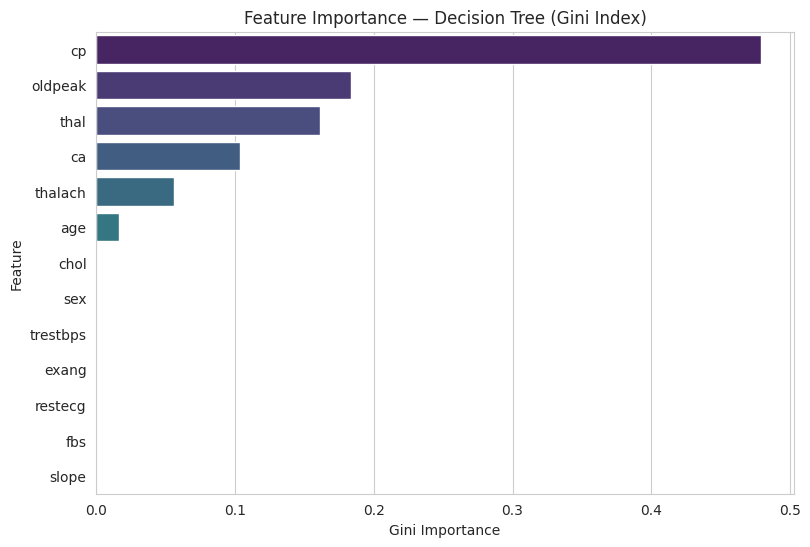

,Feature,Importance
2,cp,0.478781
9,oldpeak,0.183875
12,thal,0.161305
11,ca,0.103482
7,thalach,0.056301
0,age,0.016257
4,chol,0.000000
1,sex,0.000000
3,trestbps,0.000000
8,exang,0.000000


In [23]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_gini.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Decision Tree (Gini Index)')
plt.xlabel('Gini Importance')
plt.show()

importance_df


## 10. Effect of Tree Depth (Bias–Variance Tradeoff)

A very shallow tree underfits; a very deep tree overfits (memorizes training data, including noise). We sweep `max_depth` and compare train vs. test accuracy to find a good depth.

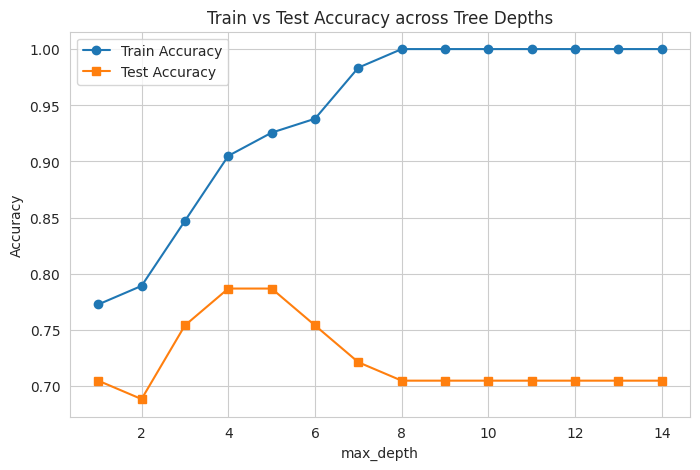

Best max_depth on test set: 4 (Test Accuracy: 0.7869)


In [24]:
depths = range(1, 15)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across Tree Depths')
plt.legend()
plt.grid(True)
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print(f"Best max_depth on test set: {best_depth} (Test Accuracy: {max(test_scores):.4f})")


## 11. Final Model with Best Depth (Gini) & Comparison with Entropy

As a bonus, let's confirm Gini's choice is reasonable by comparing it against the `entropy` (Information Gain) criterion on the same tuned depth.

In [25]:
final_gini = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=RANDOM_STATE)
final_gini.fit(X_train, y_train)
gini_acc = accuracy_score(y_test, final_gini.predict(X_test))

final_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RANDOM_STATE)
final_entropy.fit(X_train, y_train)
entropy_acc = accuracy_score(y_test, final_entropy.predict(X_test))

print(f"Gini Index Tree    -> Test Accuracy: {gini_acc:.4f}")
print(f"Entropy (Info Gain) Tree -> Test Accuracy: {entropy_acc:.4f}")


Gini Index Tree    -> Test Accuracy: 0.7869
Entropy (Info Gain) Tree -> Test Accuracy: 0.8033


In [26]:
import pickle
pickle.dump(dt_gini,open('DTModel.pkl','wb'))

## 12. Conclusion

- A Decision Tree trained with the **Gini Index** was able to classify patients as having heart disease or not with strong accuracy while remaining fully interpretable.
- **`cp` (chest pain type)`, `ca` (major vessels), `thalach` (max heart rate), `oldpeak`, and `thal`** emerged as the most influential features — consistent with medical domain knowledge about cardiovascular risk indicators.
- The extracted **if-else decision rules** in Section 8 can be handed directly to a clinician as a transparent, auditable decision-support tool — this interpretability is the key advantage of Decision Trees over black-box models like Random Forests or Neural Networks.
- The depth-sweep in Section 10 shows the classic bias-variance tradeoff: too shallow underfits, too deep overfits to training noise.
- Gini and Entropy criteria produced very similar results here, which is typical in practice — Gini is preferred by default in scikit-learn because it's computationally slightly cheaper (no log calculations).

**Possible next steps:** hyperparameter tuning with `GridSearchCV`, pruning with `ccp_alpha` (cost-complexity pruning), or comparing against ensemble methods (Random Forest, Gradient Boosting) for a performance benchmark.


**HTML Code**

In [27]:
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Heart Disease Prediction | Decision Tree Model</title>
<style>
    :root {
        --primary: #b91c2f;
        --primary-dark: #8f1424;
        --bg: #f4f1ea;
        --card-bg: #ffffff;
        --text: #2b2b2b;
        --muted: #6b6b6b;
        --border: #e2ddd2;
        --safe: #1f8a55;
        --danger: #c0293d;
    }

    * { box-sizing: border-box; }

    body {
        margin: 0;
        font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
        background: var(--bg);
        color: var(--text);
        padding: 32px 16px 64px;
    }

    .container {
        max-width: 780px;
        margin: 0 auto;
    }

    header {
        text-align: center;
        margin-bottom: 28px;
    }

    header .icon {
        font-size: 36px;
        line-height: 1;
        margin-bottom: 6px;
    }

    header h1 {
        font-size: 26px;
        margin: 0 0 6px;
        letter-spacing: -0.01em;
    }

    header p {
        color: var(--muted);
        margin: 0;
        font-size: 14px;
    }

    .card {
        background: var(--card-bg);
        border: 1px solid var(--border);
        border-radius: 14px;
        padding: 28px;
        box-shadow: 0 1px 3px rgba(0,0,0,0.04);
    }

    .section-title {
        font-size: 13px;
        text-transform: uppercase;
        letter-spacing: 0.06em;
        color: var(--primary);
        font-weight: 600;
        margin: 24px 0 12px;
        border-bottom: 1px solid var(--border);
        padding-bottom: 6px;
    }

    .section-title:first-of-type { margin-top: 0; }

    .grid {
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 16px 20px;
    }

    @media (max-width: 560px) {
        .grid { grid-template-columns: 1fr; }
    }

    .field label {
        display: block;
        font-size: 13px;
        font-weight: 600;
        margin-bottom: 6px;
        color: var(--text);
    }

    .field .hint {
        display: block;
        font-size: 11.5px;
        color: var(--muted);
        margin-top: 4px;
    }

    input[type="number"], select {
        width: 100%;
        padding: 10px 12px;
        border: 1px solid var(--border);
        border-radius: 8px;
        font-size: 14px;
        background: #fbfaf7;
        color: var(--text);
        transition: border-color 0.15s, box-shadow 0.15s;
    }

    input[type="number"]:focus, select:focus {
        outline: none;
        border-color: var(--primary);
        box-shadow: 0 0 0 3px rgba(185, 28, 47, 0.12);
        background: #fff;
    }

    button#predictBtn {
        width: 100%;
        margin-top: 28px;
        padding: 14px;
        font-size: 15px;
        font-weight: 600;
        letter-spacing: 0.01em;
        color: #fff;
        background: var(--primary);
        border: none;
        border-radius: 10px;
        cursor: pointer;
        transition: background 0.15s, transform 0.05s;
    }

    button#predictBtn:hover { background: var(--primary-dark); }
    button#predictBtn:active { transform: scale(0.99); }
    button#predictBtn:disabled { opacity: 0.6; cursor: not-allowed; }

    #result {
        margin-top: 22px;
        padding: 18px 20px;
        border-radius: 10px;
        display: none;
        align-items: center;
        gap: 14px;
    }

    #result.show { display: flex; }

    #result .badge {
        font-size: 26px;
        line-height: 1;
    }

    #result .msg-title {
        font-weight: 700;
        font-size: 16px;
        margin-bottom: 2px;
    }

    #result .msg-sub {
        font-size: 13px;
        opacity: 0.85;
    }

    #result.positive {
        background: rgba(192, 41, 61, 0.08);
        border: 1px solid rgba(192, 41, 61, 0.25);
        color: var(--danger);
    }

    #result.negative {
        background: rgba(31, 138, 85, 0.08);
        border: 1px solid rgba(31, 138, 85, 0.25);
        color: var(--safe);
    }

    #result.error {
        background: rgba(192, 41, 61, 0.08);
        border: 1px solid rgba(192, 41, 61, 0.25);
        color: var(--danger);
    }

    .disclaimer {
        text-align: center;
        font-size: 11.5px;
        color: var(--muted);
        margin-top: 18px;
        line-height: 1.5;
    }
</style>
</head>
<body>

<div class="container">
    <header>
        <div class="icon"></div>
        <h1>Heart Disease Risk Predictor</h1>
        <p>Decision Tree Classifier (Gini Index) &mdash; Enter patient details below</p>
    </header>

    <div class="card">
        <form id="predictForm">

            <div class="section-title">Patient Demographics</div>
            <div class="grid">
                <div class="field">
                    <label for="age">Age (years)</label>
                    <input type="number" id="age" name="age" min="1" max="120" placeholder="e.g. 54" required>
                </div>
                <div class="field">
                    <label for="sex">Sex</label>
                    <select id="sex" name="sex" required>
                        <option value="" disabled selected>Select</option>
                        <option value="1">Male</option>
                        <option value="0">Female</option>
                    </select>
                </div>
            </div>

            <div class="section-title">Symptoms & Vitals</div>
            <div class="grid">
                <div class="field">
                    <label for="cp">Chest Pain Type</label>
                    <select id="cp" name="cp" required>
                        <option value="" disabled selected>Select</option>
                        <option value="0">Typical Angina</option>
                        <option value="1">Atypical Angina</option>
                        <option value="2">Non-Anginal Pain</option>
                        <option value="3">Asymptomatic</option>
                    </select>
                </div>
                <div class="field">
                    <label for="trestbps">Resting Blood Pressure</label>
                    <input type="number" id="trestbps" name="trestbps" min="60" max="260" placeholder="mm Hg, e.g. 130" required>
                </div>
                <div class="field">
                    <label for="chol">Serum Cholesterol</label>
                    <input type="number" id="chol" name="chol" min="80" max="700" placeholder="mg/dl, e.g. 246" required>
                </div>
                <div class="field">
                    <label for="thalach">Max Heart Rate Achieved</label>
                    <input type="number" id="thalach" name="thalach" min="50" max="250" placeholder="e.g. 150" required>
                </div>
                <div class="field">
                    <label for="fbs">Fasting Blood Sugar &gt; 120 mg/dl</label>
                    <select id="fbs" name="fbs" required>
                        <option value="" disabled selected>Select</option>
                        <option value="1">Yes</option>
                        <option value="0">No</option>
                    </select>
                </div>
                <div class="field">
                    <label for="exang">Exercise Induced Angina</label>
                    <select id="exang" name="exang" required>
                        <option value="" disabled selected>Select</option>
                        <option value="1">Yes</option>
                        <option value="0">No</option>
                    </select>
                </div>
            </div>

            <div class="section-title">ECG & Exercise Test Results</div>
            <div class="grid">
                <div class="field">
                    <label for="restecg">Resting ECG Result</label>
                    <select id="restecg" name="restecg" required>
                        <option value="" disabled selected>Select</option>
                        <option value="0">Normal</option>
                        <option value="1">ST-T Wave Abnormality</option>
                        <option value="2">Left Ventricular Hypertrophy</option>
                    </select>
                </div>
                <div class="field">
                    <label for="oldpeak">ST Depression (Oldpeak)</label>
                    <input type="number" step="0.1" id="oldpeak" name="oldpeak" min="0" max="10" placeholder="e.g. 1.4" required>
                </div>
                <div class="field">
                    <label for="slope">Slope of Peak Exercise ST Segment</label>
                    <select id="slope" name="slope" required>
                        <option value="" disabled selected>Select</option>
                        <option value="0">Upsloping</option>
                        <option value="1">Flat</option>
                        <option value="2">Downsloping</option>
                    </select>
                </div>
                <div class="field">
                    <label for="ca">Major Vessels Colored by Fluoroscopy</label>
                    <select id="ca" name="ca" required>
                        <option value="" disabled selected>Select</option>
                        <option value="0">0</option>
                        <option value="1">1</option>
                        <option value="2">2</option>
                        <option value="3">3</option>
                        <option value="4">4</option>
                    </select>
                </div>
                <div class="field">
                    <label for="thal">Thalassemia</label>
                    <select id="thal" name="thal" required>
                        <option value="" disabled selected>Select</option>
                        <option value="0">Unknown</option>
                        <option value="1">Normal</option>
                        <option value="2">Fixed Defect</option>
                        <option value="3">Reversible Defect</option>
                    </select>
                </div>
            </div>

            <button type="submit" id="predictBtn">Predict</button>
        </form>

        <div id="result"></div>
    </div>

    <p class="disclaimer">This tool is built by Dr. Sachin Balawant Takmare</p>
</div>

<script>
const form = document.getElementById('predictForm');
const resultBox = document.getElementById('result');
const btn = document.getElementById('predictBtn');

form.addEventListener('submit', async function (e) {
    e.preventDefault();

    const formData = new FormData(form);
    const payload = {};
    formData.forEach((value, key) => { payload[key] = value; });

    btn.disabled = true;
    btn.textContent = 'Predicting...';
    resultBox.className = '';
    resultBox.style.display = 'none';

    try {
        const response = await fetch('/predict', {
            method: 'POST',
            headers: { 'Content-Type': 'application/json' },
            body: JSON.stringify(payload)
        });

        const data = await response.json();

        if (!response.ok) {
            throw new Error(data.error || 'Something went wrong.');
        }

        const isPositive = data.prediction === 1;
        resultBox.className = 'show ' + (isPositive ? 'positive' : 'negative');
        resultBox.innerHTML = `
            <div class="badge">${isPositive ? '&#9888;&#65039;' : '&#9989;'}</div>
            <div>
                <div class="msg-title">${data.label}</div>
                <div class="msg-sub">Model confidence: ${data.confidence}%</div>
            </div>
        `;
    } catch (err) {
        resultBox.className = 'show error';
        resultBox.innerHTML = `
            <div class="badge">&#9888;&#65039;</div>
            <div>
                <div class="msg-title">Prediction failed</div>
                <div class="msg-sub">${err.message}</div>
            </div>
        `;
    } finally {
        btn.disabled = false;
        btn.textContent = 'Predict';
    }
});
</script>

</body>
</html>


SyntaxError: invalid decimal literal (414267942.py, line 27)

**Flask Code**

In [ ]:
from flask import Flask, render_template, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Decision Tree model (Gini index)
# Make sure DTModel.pkl is in the SAME folder as this app.py
with open('DTModel.pkl', 'rb') as f:
    model = pickle.load(f)

# Feature order MUST exactly match the order used during training
FEATURE_ORDER = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]


@app.route('/')
def home():
    return render_template('index.html')


@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        # Validate all required fields are present
        missing = [f for f in FEATURE_ORDER if f not in data or data[f] == '']
        if missing:
            return jsonify({'error': f'Missing values for: {", ".join(missing)}'}), 400

        # Build the feature vector in the correct order
        features = [float(data[f]) for f in FEATURE_ORDER]
        input_array = np.array(features).reshape(1, -1)

        prediction = model.predict(input_array)[0]
        probabilities = model.predict_proba(input_array)[0]
        confidence = round(float(max(probabilities)) * 100, 2)

        result = {
            'prediction': int(prediction),
            'label': 'Heart Disease Detected' if prediction == 1 else 'No Heart Disease Detected',
            'confidence': confidence
        }
        return jsonify(result)

    except ValueError:
        return jsonify({'error': 'All fields must be valid numbers.'}), 400
    except Exception as e:
        return jsonify({'error': str(e)}), 500


if __name__ == '__main__':
    app.run(debug=True)
